In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

STEP 1 – EXPLORATORY DATA ANALYSIS (EDA)

In [15]:
# 1.1 Load Dataset
df = pd.read_csv("synthetic_dataset.csv")
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [16]:
# 1.2 Struktur Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB


In [17]:
# 1.3 Cek Missing Values
df.isnull().sum()

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64

In [18]:
# 1.4 Statistik Deskriptif
df.describe()

,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


In [19]:
# 1.5 Identifikasi Tipe Data
# Pisahkan fitur dan target
X = df.drop(columns="Stock")
y = df["Stock"]

# Hapus missing pada target
mask = y.notnull()
X = X[mask]
y = y[mask]

# Identifikasi ulang tipe data HANYA dari X
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

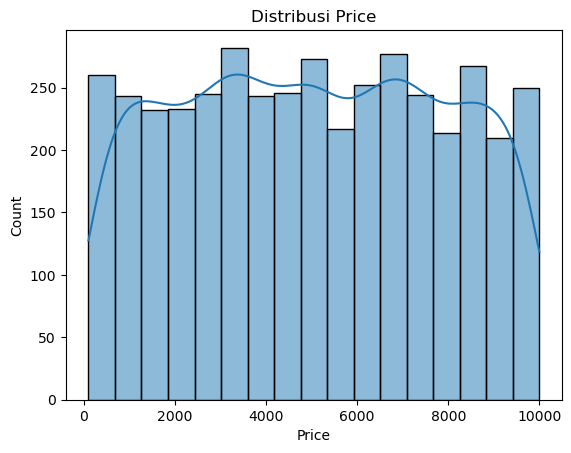

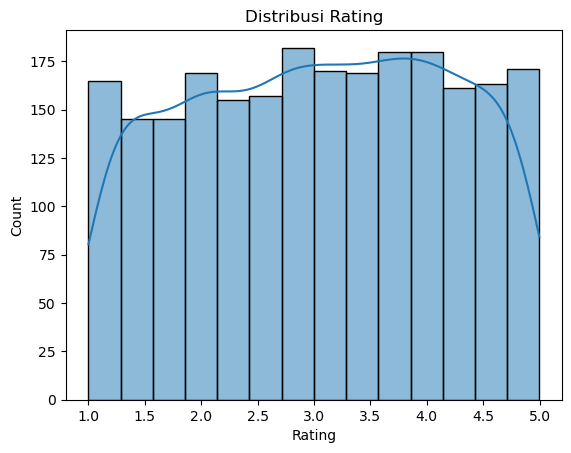

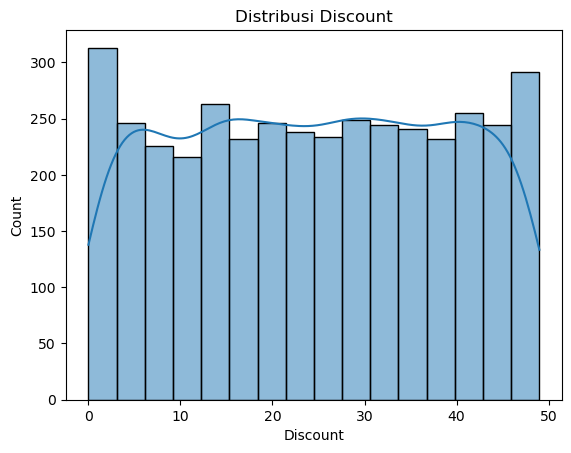

In [20]:
# 1.6 Visualisasi Distribusi Numerik
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()

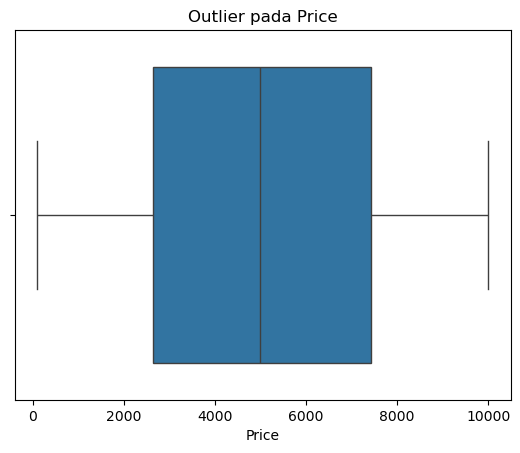

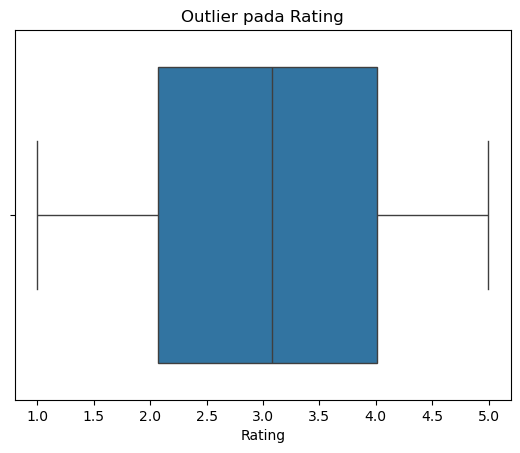

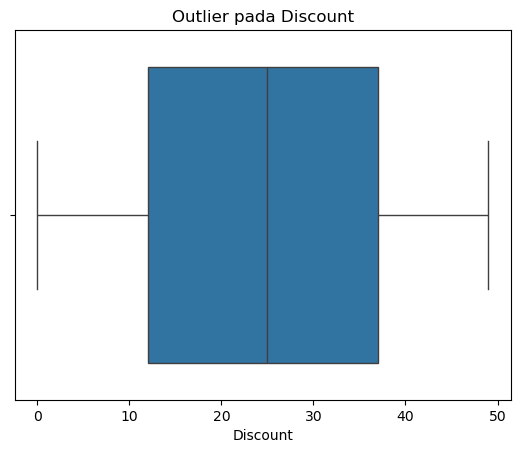

In [21]:
# 1.7 Boxplot (Outlier Check)
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier pada {col}")
    plt.show()

STEP 2 – IMPUTASI DATA

In [22]:
# 2.1 Pisahkan Target dan Fitur
X = df.drop(columns="Stock")
y = df["Stock"]

In [23]:
# 2.2 Hapus Missing pada Target
mask = y.notnull()
X = X[mask]
y = y[mask]

In [24]:
# 2.3 Imputasi Fitur Numerik (Median)
num_imputer = SimpleImputer(strategy="median")
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

In [25]:
# 2.4 Imputasi Fitur Kategorikal (Mode)
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

STEP 3 – ENCODING DATA KATEGORIKAL

In [26]:
# 3.1 One-Hot Encoding
encoder = OneHotEncoder(drop="first", sparse_output=False)

encoded_cat = encoder.fit_transform(X[categorical_cols])
encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

In [27]:
# 3.2 Gabungkan dengan Fitur Numerik
X_final = pd.concat(
    [X[numerical_cols], encoded_cat_df],
    axis=1
)

X_final.head()

,Price,Rating,Discount,Category_B,Category_C,Category_D
2,4004.0,3.081697,0.0,0.0,1.0,0.0
4,1817.0,3.081697,23.0,0.0,1.0,0.0
6,667.0,3.668341,41.0,0.0,1.0,0.0
7,7125.0,4.983998,7.0,0.0,0.0,0.0
8,2777.0,2.678384,6.0,0.0,0.0,0.0


STEP 4 – NORMALISASI / STANDARISASI

In [28]:
# 4.1 Standardisasi Fitur Numerik
scaler = StandardScaler()
X_final[numerical_cols] = scaler.fit_transform(X_final[numerical_cols])

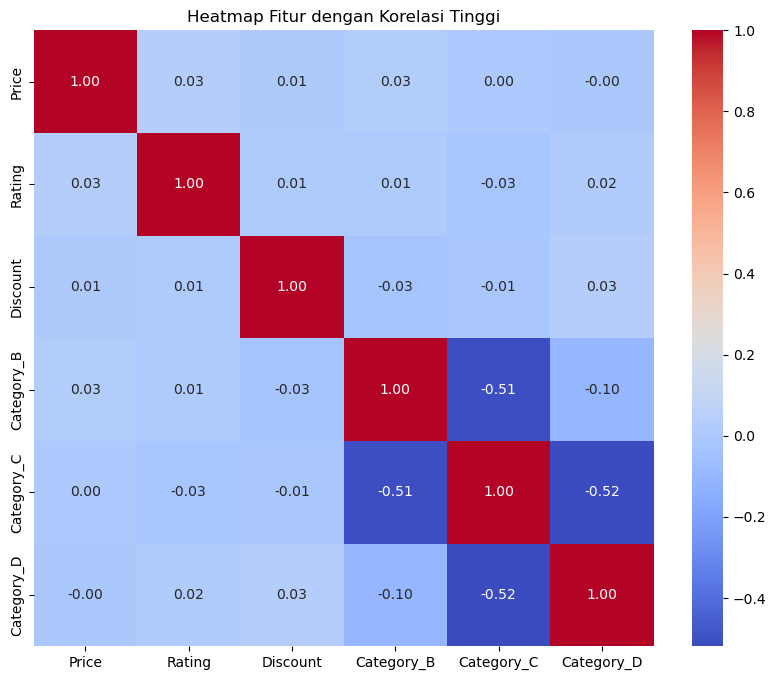

In [38]:
# heatmap validasi fitur
corr = X_final.corr()

high_corr_features = corr.columns[
    (corr.abs() > 0.7).any()
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr.loc[high_corr_features, high_corr_features],
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap Fitur dengan Korelasi Tinggi")
plt.show()


STEP 5 – TRAIN TEST SPLIT

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

STEP 6 – PEMBANGUNAN MODEL (TERPISAH)

In [40]:
# 6.1 Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [41]:
# 6.2 K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [42]:
# 6.3 Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [43]:
# 6.4 Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

STEP 7 – EVALUASI & PERBANDINGAN MODEL

In [44]:
# 7.1 Akurasi
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

results

{'Logistic Regression': 0.46179401993355484,
 'KNN': 0.5116279069767442,
 'Decision Tree': 0.4883720930232558,
 'Random Forest': 0.5166112956810631}

In [45]:
# 7.2 Classification Report (Model Terbaik)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

    In Stock       0.52      0.53      0.52       303
Out of Stock       0.51      0.51      0.51       299

    accuracy                           0.52       602
   macro avg       0.52      0.52      0.52       602
weighted avg       0.52      0.52      0.52       602

